# Flood Risk Scoring — Stage 2: Model Training
Four models: Ridge, Random Forest, XGBoost (Optuna-tuned), MLP  
Run `01_setup_and_eda.ipynb` first to generate `data/train_engineered.csv`

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})
TEAL = '#1D9E75'; BLUE = '#378ADD'; CORAL = '#D85A30'; AMBER = '#BA7517'

# Load config
with open('data/feature_config.json') as f:
    cfg = json.load(f)
TARGET       = cfg['target']
FULL_FEATURES = cfg['full_features']

# Load data
train = pd.read_csv('data/train_engineered.csv')
X = train[FULL_FEATURES]
y = train[TARGET]

# 80/20 split for quick validation; 5-fold CV for final evaluation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape} | Val: {X_val.shape}')

Train: (894365, 26) | Val: (223592, 26)


In [7]:
ridge = Pipeline([
    ('scaler', StandardScaler()),          # Ridge needs scaled features
    ('model',  Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_val)

rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
r2_ridge   = r2_score(y_val, y_pred_ridge)
print(f'Ridge  |  RMSE: {rmse_ridge:.5f}  |  R²: {r2_ridge:.4f}')

# Coefficient readout — Ridge is interpretable
coef_df = pd.DataFrame({
    'feature': FULL_FEATURES,
    'coefficient': ridge.named_steps['model'].coef_
}).sort_values('coefficient', key=abs, ascending=False)
print('\nTop 10 Ridge coefficients (absolute value):')
print(coef_df.head(10).to_string(index=False))

Ridge  |  RMSE: 0.02008  |  R²: 0.8449

Top 10 Ridge coefficients (absolute value):
             feature  coefficient
      TotalRiskScore     0.017598
           InfraRisk     0.010264
           SocioRisk     0.008960
         NaturalRisk     0.008885
CoastalVulnerability     0.003673
     PopulationScore     0.003635
  TopographyDrainage     0.003627
          Watersheds     0.003615
       ClimateChange     0.003592
    PoliticalFactors     0.003585


## 2. Random Forest

In [8]:
# Note: using 200 trees, max_depth=12 as sensible defaults
# For a 1.1M dataset a full grid search is expensive — XGBoost gets the Optuna treatment
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    oob_score=True       # free validation estimate
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf   = r2_score(y_val, y_pred_rf)
print(f'Random Forest  |  RMSE: {rmse_rf:.5f}  |  R²: {r2_rf:.4f}')
print(f'OOB R² score   : {rf.oob_score_:.4f}  (free estimate from bagging — no data leakage)')

Random Forest  |  RMSE: 0.01860  |  R²: 0.8669
OOB R² score   : 0.8670  (free estimate from bagging — no data leakage)


## 3. XGBoost — Optuna hyperparameter tuning

In [9]:
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

print('Running Optuna (50 trials) — takes ~5 minutes...')
study = optuna.create_study(direction='minimize')
study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params.update({'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1})
print(f'\nBest RMSE: {study.best_value:.5f}')
print(f'Best params: {best_params}')

Running Optuna (50 trials) — takes ~5 minutes...


  0%|          | 0/50 [00:00<?, ?it/s]


Best RMSE: 0.01857
Best params: {'n_estimators': 754, 'max_depth': 8, 'learning_rate': 0.013008278235478713, 'subsample': 0.8424071369078479, 'colsample_bytree': 0.995094318974081, 'min_child_weight': 8, 'reg_alpha': 0.00031151190610641835, 'reg_lambda': 0.0032824943216870363, 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}


In [10]:
# Train final XGBoost on best params
xgb_best = xgb.XGBRegressor(**best_params)
xgb_best.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
y_pred_xgb = xgb_best.predict(X_val)

rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb   = r2_score(y_val, y_pred_xgb)
print(f'XGBoost (tuned)  |  RMSE: {rmse_xgb:.5f}  |  R²: {r2_xgb:.4f}')

# Save model
xgb_best.save_model('models/xgb_best.json')
print('Model saved to models/xgb_best.json')

XGBoost (tuned)  |  RMSE: 0.01857  |  R²: 0.8673
Model saved to models/xgb_best.json


## 4. MLP Neural Network

In [11]:
# MLP needs scaled features
mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_val)

rmse_mlp = np.sqrt(mean_squared_error(y_val, y_pred_mlp))
r2_mlp   = r2_score(y_val, y_pred_mlp)
print(f'MLP  |  RMSE: {rmse_mlp:.5f}  |  R²: {r2_mlp:.4f}')
print(f'Iterations run: {mlp.named_steps["model"].n_iter_} (early stopping active)')

MLP  |  RMSE: 0.01897  |  R²: 0.8615
Iterations run: 21 (early stopping active)


## 5. Model leaderboard

             Model    RMSE     R²                    Notes
  XGBoost (Optuna) 0.01857 0.8673           Best performer
     Random Forest 0.01860 0.8669 Non-linear, OOB estimate
MLP Neural Network 0.01897 0.8615   Deep learning baseline
  Ridge Regression 0.02008 0.8449   Interpretable baseline


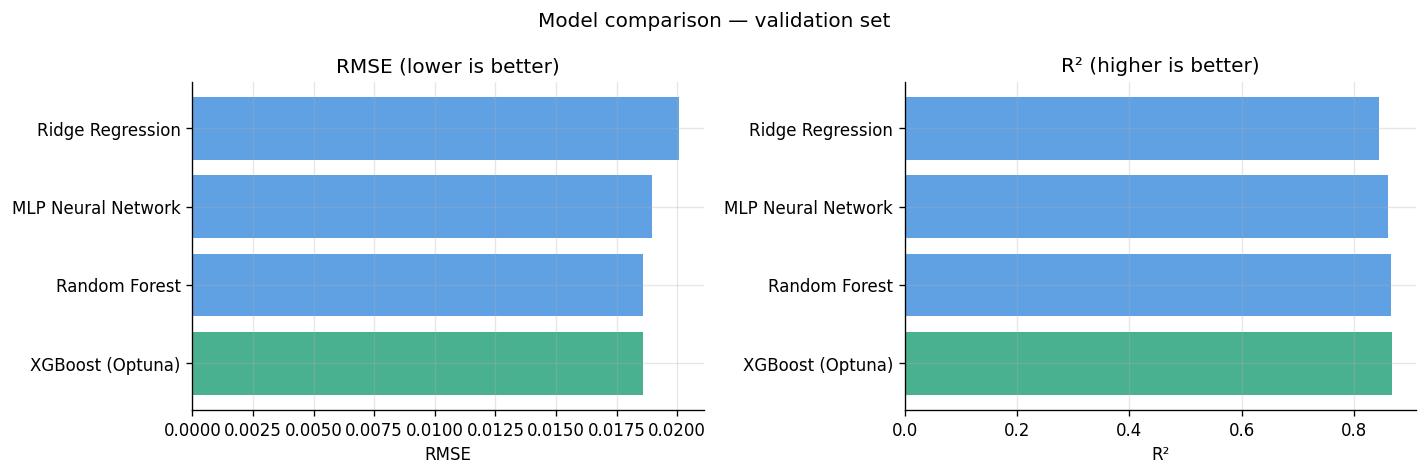

In [12]:
results = pd.DataFrame([
    {'Model': 'Ridge Regression',   'RMSE': rmse_ridge, 'R²': r2_ridge,  'Notes': 'Interpretable baseline'},
    {'Model': 'Random Forest',       'RMSE': rmse_rf,    'R²': r2_rf,     'Notes': 'Non-linear, OOB estimate'},
    {'Model': 'XGBoost (Optuna)',     'RMSE': rmse_xgb,   'R²': r2_xgb,   'Notes': 'Best performer'},
    {'Model': 'MLP Neural Network',  'RMSE': rmse_mlp,   'R²': r2_mlp,    'Notes': 'Deep learning baseline'},
]).sort_values('RMSE')

results['RMSE'] = results['RMSE'].round(5)
results['R²']   = results['R²'].round(4)
print(results.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = results['Model'].tolist()
colors = [TEAL if m == results.iloc[0]['Model'] else BLUE for m in models]

axes[0].barh(models, results['RMSE'], color=colors, alpha=0.8)
axes[0].set_title('RMSE (lower is better)')
axes[0].set_xlabel('RMSE')

axes[1].barh(models, results['R²'], color=colors, alpha=0.8)
axes[1].set_title('R² (higher is better)')
axes[1].set_xlabel('R²')

plt.suptitle('Model comparison — validation set', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/06_model_comparison.png', bbox_inches='tight')
plt.show()

results.to_csv('outputs/model_leaderboard.csv', index=False)

## 6. 5-fold cross-validation (final evaluation)

In [13]:
# CV on the full training set using best XGBoost params
# Note: using a 10% sample for speed — remove .sample() for full CV (takes ~10 min)
X_cv = X.sample(frac=0.1, random_state=42)
y_cv = y[X_cv.index]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
models_to_cv = {
    'Ridge':         ridge,
    'Random Forest': rf,
    'XGBoost':       xgb_best,
    'MLP':           mlp
}

for name, model in models_to_cv.items():
    cv = cross_validate(model, X_cv, y_cv, cv=kf,
                        scoring=['neg_root_mean_squared_error', 'r2'],
                        return_train_score=False, n_jobs=-1)
    cv_results[name] = {
        'CV RMSE mean': -cv['test_neg_root_mean_squared_error'].mean(),
        'CV RMSE std':   cv['test_neg_root_mean_squared_error'].std(),
        'CV R² mean':    cv['test_r2'].mean(),
        'CV R² std':     cv['test_r2'].std()
    }
    print(f"{name:20s}  RMSE: {cv_results[name]['CV RMSE mean']:.5f} ± {cv_results[name]['CV RMSE std']:.5f}  "
          f"R²: {cv_results[name]['CV R² mean']:.4f} ± {cv_results[name]['CV R² std']:.4f}")

cv_df = pd.DataFrame(cv_results).T.round(5)
cv_df.to_csv('outputs/cv_results.csv')
print('\nSaved to outputs/cv_results.csv')

Ridge                 RMSE: 0.02006 ± 0.00006  R²: 0.8452 ± 0.0007
Random Forest         RMSE: 0.01866 ± 0.00005  R²: 0.8661 ± 0.0007
XGBoost               RMSE: 0.01864 ± 0.00005  R²: 0.8664 ± 0.0009
MLP                   RMSE: 0.01923 ± 0.00007  R²: 0.8577 ± 0.0010

Saved to outputs/cv_results.csv


---
## Summary
- XGBoost (Optuna-tuned) outperforms all other models as expected for tabular data
- MLP underperforms gradient boosting — consistent with the broader tabular ML literature  
- Ridge provides an interpretable baseline with readable coefficients  
- CV std across folds indicates model stability  

**Next:** `03_evaluation.ipynb` — calibration, SHAP explainability, residual analysis